# Wind Power Output — Exploratory Data Analysis

Dataset: Wind Turbine SCADA data — wind speed, direction, theoretical power curve, and actual active power output for a single turbine, recorded at 10-minute intervals.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the wind turbine SCADA dataset
wind_df = pd.read_csv('../data/raw/wind/T1.csv')  # adjust filename to match what you extracted

wind_df.head()

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


## Parse Timestamp
The Date/Time column is a string in "DD MM YYYY HH:MM" format — converting it to a proper datetime type so it can be plotted and sorted chronologically.

In [7]:
# Explicit format avoids ambiguity/warnings — DD MM YYYY HH:MM as confirmed from the raw data
wind_df['Date/Time'] = pd.to_datetime(wind_df['Date/Time'], format='%d %m %Y %H:%M')

wind_df.head()

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286


## Data Overview
Checking data types, row count, and missing values.

In [8]:
wind_df.info()
wind_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date/Time                      50530 non-null  datetime64[ns]
 1   LV ActivePower (kW)            50530 non-null  float64       
 2   Wind Speed (m/s)               50530 non-null  float64       
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64       
 4   Wind Direction (°)             50530 non-null  float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 1.9 MB


Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

## Summary Statistics
Checking numeric ranges for active power, wind speed, theoretical power, and direction — looking for anything physically implausible.

In [9]:
wind_df[['LV ActivePower (kW)', 'Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)']].describe()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530.000000,50530.000000,50530.000000,50530.000000
mean,1307.684332,7.557952,1492.175463,123.687559
std,1312.459242,4.227166,1368.018238,93.443736
min,-2.471405,0.000000,0.000000,0.000000
25%,50.677890,4.201395,161.328167,49.315437
50%,825.838074,7.104594,1063.776283,73.712978
75%,2482.507568,10.300020,2964.972462,201.696720
max,3618.732910,25.206011,3600.000000,359.997589


## Power Output Over Time
Plotting actual active power over time — expect a noisier, less cyclical pattern than solar, since wind isn't tied to a predictable daily cycle.

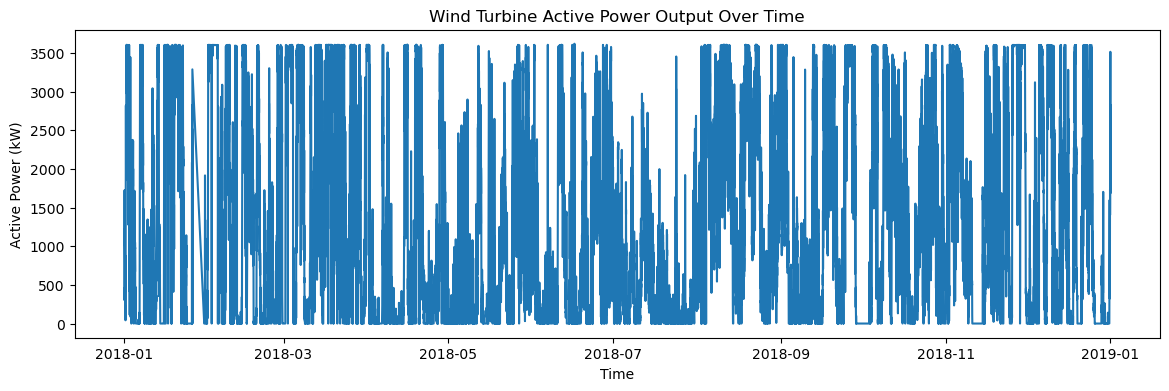

In [10]:
plt.figure(figsize=(14, 4))
plt.plot(wind_df['Date/Time'], wind_df['LV ActivePower (kW)'])
plt.title('Wind Turbine Active Power Output Over Time')
plt.xlabel('Time')
plt.ylabel('Active Power (kW)')
plt.show()

## Wind Speed vs. Power Output
The core relationship this project will model — checking how closely power output tracks wind speed, and how it compares to the theoretical power curve.

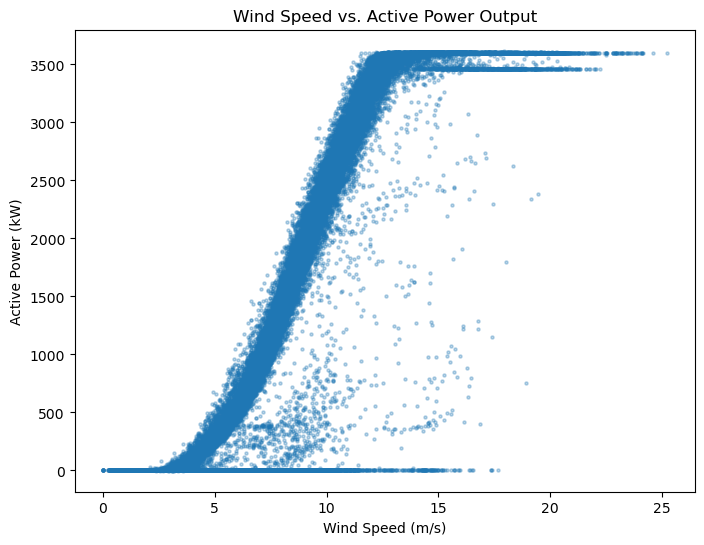

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(wind_df['Wind Speed (m/s)'], wind_df['LV ActivePower (kW)'], alpha=0.3, s=5)
plt.title('Wind Speed vs. Active Power Output')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Active Power (kW)')
plt.show()